# Courtship Analysis Variability Across Technical Replicates

This notebook analyzes the reproducibility of courtship analysis by examining the variability in courtship scores and confidence values across technical replicates.

In [1]:
import os
import json
import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for our plots
#plt.style.use('seaborn-whitegrid')
sns.set_context("notebook", font_scale=1.2)

## Helper Functions

First, we define functions to extract base filenames and analyze the JSON files.

In [2]:
def extract_base_filename(json_path):
    """Extract base filename without the numerical suffix"""
    # Match pattern until the timestamp, excluding the -N suffix
    pattern = r'(.*_\d{8}_\d{6}_\d{3})'
    match = re.search(pattern, json_path)
    if match:
        return match.group(1)
    return None

In [3]:
def analyze_json_variability(directory):
    """Analyze JSON files for variability in courtship scores and confidence values."""
    # Find all JSON files
    json_files = glob.glob(os.path.join(directory, "**", "*.json"), recursive=True)
    print(f"Found {len(json_files)} JSON files to analyze")
    
    if len(json_files) == 0:
        print(f"No JSON files found in directory: {directory}")
        return pd.DataFrame()
    
    # Group files by their base name
    groups = {}
    for file_path in json_files:
        base_name = extract_base_filename(file_path)
        if base_name:
            if base_name not in groups:
                groups[base_name] = []
            groups[base_name].append(file_path)
    
    print(f"Grouped into {len(groups)} unique base names")
    
    # Collect data for each group
    results = []
    for base_name, files in groups.items():
        print(f"Processing group: {os.path.basename(base_name)} ({len(files)} files)")
        scores = []
        confidences = []
        phases = []
        
        for file_path in files:
            try:
                with open(file_path, 'r') as f:
                    data = json.load(f)
                
                # Check if required fields exist and are numeric
                if 'courtship_score' in data and 'confidence' in data:
                    # Convert to float if string
                    try:
                        score = float(data['courtship_score'])
                        confidence = float(data['confidence'])
                        scores.append(score)
                        confidences.append(confidence)
                        
                        if 'courtship_phase' in data:
                            phases.append(data['courtship_phase'])
                    except (ValueError, TypeError) as e:
                        print(f"Error converting values in file {file_path}: {e}")
                        print(f"courtship_score: {data['courtship_score']} (type: {type(data['courtship_score'])})")
                        print(f"confidence: {data['confidence']} (type: {type(data['confidence'])})")
                else:
                    missing_fields = []
                    if 'courtship_score' not in data:
                        missing_fields.append('courtship_score')
                    if 'confidence' not in data:
                        missing_fields.append('confidence')
                    print(f"File {file_path} is missing required fields: {', '.join(missing_fields)}")
            
            except json.JSONDecodeError as e:
                print(f"Error decoding JSON in file: {file_path}")
                print(f"Error details: {str(e)}")
                continue
            except Exception as e:
                print(f"Error processing file {file_path}: {str(e)}")
                print(f"Exception type: {type(e).__name__}")
                continue
        
        # Calculate statistics if we have data
        if scores and confidences:
            # Safety check to ensure all values are numeric
            if not all(isinstance(x, (int, float)) for x in scores):
                print(f"Warning: Non-numeric values in scores for {base_name}")
                scores = [float(s) for s in scores if isinstance(s, (int, float)) or (isinstance(s, str) and s.replace('.', '', 1).isdigit())]
            
            if not all(isinstance(x, (int, float)) for x in confidences):
                print(f"Warning: Non-numeric values in confidences for {base_name}")
                confidences = [float(c) for c in confidences if isinstance(c, (int, float)) or (isinstance(c, str) and c.replace('.', '', 1).isdigit())]
            
            if not scores or not confidences:
                print(f"Skip {base_name}: No valid numeric data after filtering")
                continue
            
            try:
                short_name = os.path.basename(base_name)
                results.append({
                    'base_name': short_name,
                    'mean_score': sum(scores) / len(scores),
                    'std_score': pd.Series(scores).std(),
                    'min_score': min(scores),
                    'max_score': max(scores),
                    'mean_confidence': sum(confidences) / len(confidences),
                    'std_confidence': pd.Series(confidences).std(),
                    'min_confidence': min(confidences),
                    'max_confidence': max(confidences),
                    'sample_size': len(scores),
                    'phases': phases,
                    'scores': scores,
                    'confidences': confidences
                })
            except Exception as e:
                print(f"Error calculating statistics for {base_name}: {str(e)}")
                print(f"Scores: {scores}")
                print(f"Confidences: {confidences}")
        else:
            print(f"Skip {base_name}: No valid score or confidence data found")
    
    if not results:
        print("No valid data collected from any group.")
        return pd.DataFrame()
    
    print(f"Successfully analyzed {len(results)} groups with valid data")
    return pd.DataFrame(results)

## Data Analysis

Now let's analyze the JSON files in our directory.

In [4]:
# Directory containing the JSON files - adjust this path as needed
directory = "output/2025-01-29_17-41-03_076e2825a7274661bd0697c42d6fa4c0__1920x1088@25fps-28q_merged/roi/"

# Analyze the data
df_results = analyze_json_variability(directory)

if df_results.empty:
    print("No valid data found for analysis.")
else:
    print(f"Successfully analyzed data for {len(df_results)} groups")

Found 1641 JSON files to analyze
Grouped into 546 unique base names
Processing group: 2025-01-29_17-41-03_076e2825a7274661bd0697c42d6fa4c0__1920x1088@25fps-28q_merged_frame_0071_arena_2_20250307_110603_178 (3 files)
Processing group: 2025-01-29_17-41-03_076e2825a7274661bd0697c42d6fa4c0__1920x1088@25fps-28q_merged_frame_0064_arena_3_20250307_110554_969 (3 files)
File output/2025-01-29_17-41-03_076e2825a7274661bd0697c42d6fa4c0__1920x1088@25fps-28q_merged/roi/2025-01-29_17-41-03_076e2825a7274661bd0697c42d6fa4c0__1920x1088@25fps-28q_merged_frame_0064_arena_3_20250307_110554_969-2.json is missing required fields: courtship_score, confidence
Processing group: 2025-01-29_17-41-03_076e2825a7274661bd0697c42d6fa4c0__1920x1088@25fps-28q_merged_frame_0002_arena_1_20250307_110417_988 (3 files)
Processing group: 2025-01-29_17-41-03_076e2825a7274661bd0697c42d6fa4c0__1920x1088@25fps-28q_merged_frame_0035_arena_3_20250307_110513_521 (3 files)
File output/2025-01-29_17-41-03_076e2825a7274661bd0697c42d6f

## Results Overview

Let's take a look at the data we've gathered:

In [5]:
# Display the first few rows of our results
df_results.head()

,base_name,mean_score,std_score,min_score,max_score,mean_confidence,std_confidence,min_confidence,max_confidence,sample_size,phases,scores,confidences
0,2025-01-29_17-41-03_076e2825a7274661bd0697c42d...,0.833333,5.773503e-02,0.8,0.9,0.933333,0.028868,0.90,0.95,3,"[wing_extension, lingering_contact, attempted_...","[0.8, 0.8, 0.9]","[0.95, 0.9, 0.95]"
1,2025-01-29_17-41-03_076e2825a7274661bd0697c42d...,0.600000,2.828427e-01,0.4,0.8,0.800000,0.141421,0.70,0.90,2,"[initial_detection, orientation]","[0.4, 0.8]","[0.7, 0.9]"
2,2025-01-29_17-41-03_076e2825a7274661bd0697c42d...,0.800000,1.359740e-16,0.8,0.8,0.900000,0.050000,0.85,0.95,3,"[wing_extension, wing_extension, wing_extension]","[0.8, 0.8, 0.8]","[0.9, 0.85, 0.95]"
3,2025-01-29_17-41-03_076e2825a7274661bd0697c42d...,0.800000,0.000000e+00,0.8,0.8,0.900000,0.000000,0.90,0.90,2,"[probable_copulation, tentative_copulation]","[0.8, 0.8]","[0.9, 0.9]"
4,2025-01-29_17-41-03_076e2825a7274661bd0697c42d...,0.833333,5.773503e-02,0.8,0.9,0.933333,0.028868,0.90,0.95,3,"[attempted_copulation, winging, attempted_copu...","[0.9, 0.8, 0.8]","[0.95, 0.95, 0.9]"


In [6]:
# Calculate summary statistics
summary = df_results[['base_name', 'mean_score', 'std_score', 'mean_confidence', 
                      'std_confidence', 'sample_size']].sort_values('mean_score', ascending=False)

# Calculate coefficient of variation (CV) for better comparison of reproducibility
summary['score_cv'] = (summary['std_score'] / summary['mean_score']) * 100
summary['confidence_cv'] = (summary['std_confidence'] / summary['mean_confidence']) * 100

# Display summary table
summary

,base_name,mean_score,std_score,mean_confidence,std_confidence,sample_size,score_cv,confidence_cv
139,2025-01-29_17-41-03_076e2825a7274661bd0697c42d...,3.266667,4.186088,3.783333,4.950842,3,128.145553,130.859251
250,2025-01-29_17-41-03_076e2825a7274661bd0697c42d...,1.000000,NaN,0.990000,NaN,1,NaN,NaN
100,2025-01-29_17-41-03_076e2825a7274661bd0697c42d...,0.966667,0.057735,0.983333,0.028868,3,5.972589,2.935679
416,2025-01-29_17-41-03_076e2825a7274661bd0697c42d...,0.950000,0.070711,0.925000,0.035355,2,7.443229,3.822199
190,2025-01-29_17-41-03_076e2825a7274661bd0697c42d...,0.950000,0.070711,0.970000,0.028284,2,7.443229,2.915904
...,...,...,...,...,...,...,...,...
279,2025-01-29_17-41-03_076e2825a7274661bd0697c42d...,0.316667,0.284312,0.433333,0.378594,3,89.782748,87.367821
436,2025-01-29_17-41-03_076e2825a7274661bd0697c42d...,0.300000,0.424264,0.400000,0.565685,2,141.421356,141.421356
187,2025-01-29_17-41-03_076e2825a7274661bd0697c42d...,0.100000,NaN,0.900000,NaN,1,NaN,NaN
230,2025-01-29_17-41-03_076e2825a7274661bd0697c42d...,0.066667,0.945163,0.500000,0.458258,3,1417.744688,91.651514


## Visualizing Score and Confidence Variability

### Box Plots

Box plots help us visualize the distribution and spread of scores and confidence values across technical replicates.

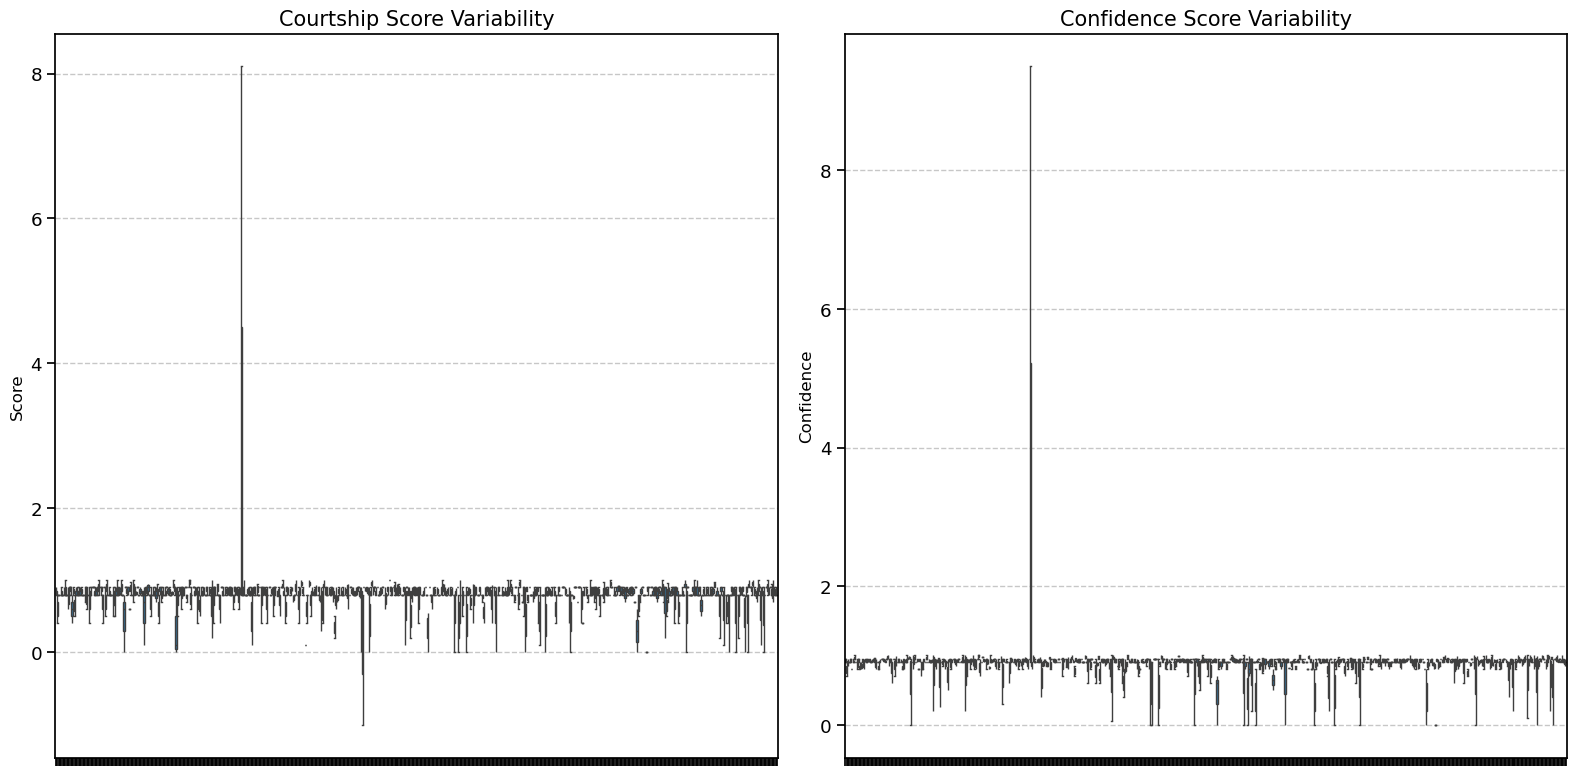

In [7]:
# Create a figure with two subplots for score and confidence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Create exploded DataFrames suitable for boxplot
scores_df = pd.DataFrame({
    'base_name': np.repeat(df_results['base_name'], df_results['scores'].apply(len)),
    'value': np.concatenate(df_results['scores'].tolist())
})

confidences_df = pd.DataFrame({
    'base_name': np.repeat(df_results['base_name'], df_results['confidences'].apply(len)),
    'value': np.concatenate(df_results['confidences'].tolist())
})

# Plot 1: Score variability
sns.boxplot(data=scores_df, x='base_name', y='value', orient='v', ax=ax1)
# Hide x-axis labels
ax1.set_xticklabels([])
ax1.set_xlabel("")
ax1.set_title('Courtship Score Variability', fontsize=15)
ax1.set_ylabel('Score', fontsize=12)

# Plot 2: Confidence variability
sns.boxplot(data=confidences_df, x='base_name', y='value', orient='v', ax=ax2)
# Hide x-axis labels
ax2.set_xticklabels([])
ax2.set_xlabel("")
ax2.set_title('Confidence Score Variability', fontsize=15)
ax2.set_ylabel('Confidence', fontsize=12)

# Add a small grid for better reference
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Error Bars Plot

This plot shows the mean values with standard deviation error bars to visualize the variability across replicates.

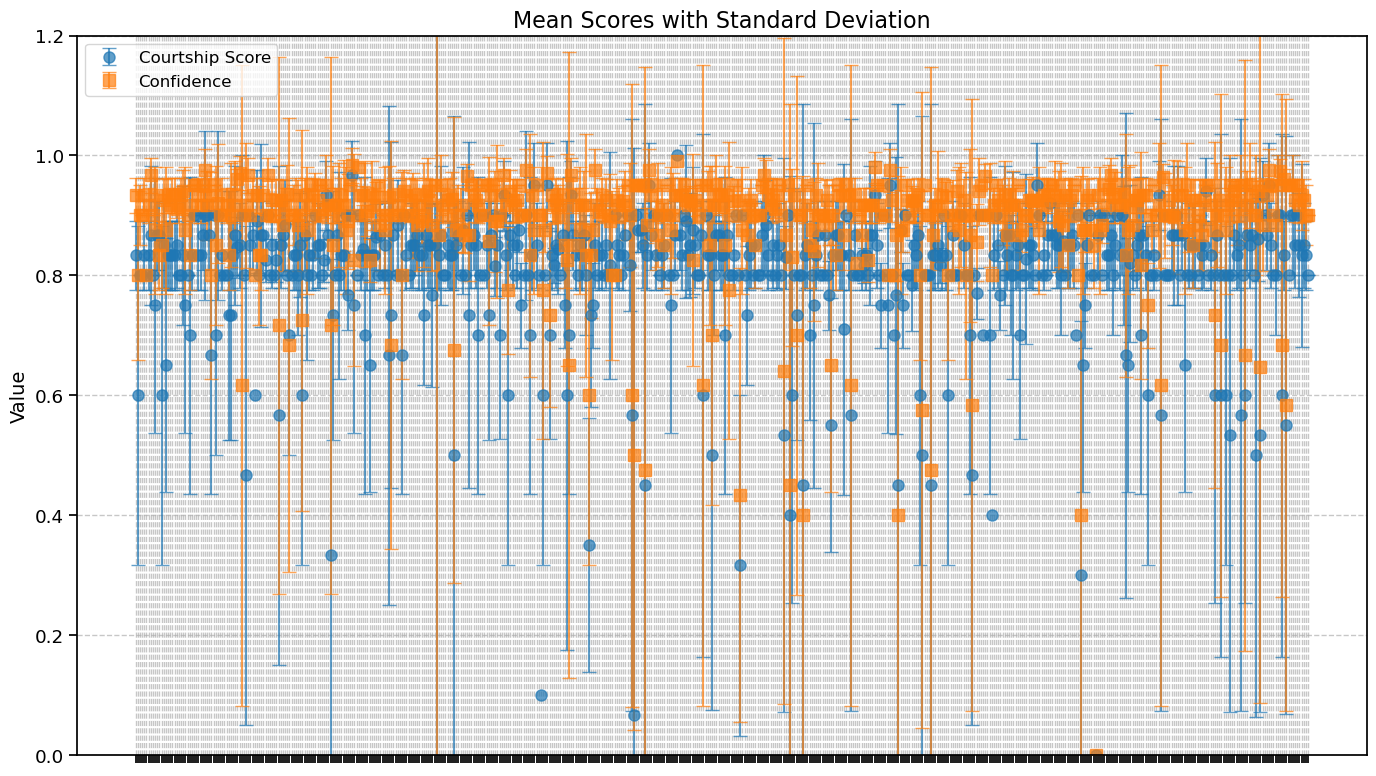

In [16]:
plt.figure(figsize=(14, 8))

# Create numerical x positions instead of using string labels directly
x_positions = np.arange(len(df_results))

# Plot means with error bars using numeric positions
plt.errorbar(
    x_positions, 
    df_results['mean_score'], 
    yerr=df_results['std_score'], 
    fmt='o', 
    label='Courtship Score', 
    capsize=5,
    alpha=0.7,
    markersize=8
)
plt.errorbar(
    x_positions, 
    df_results['mean_confidence'], 
    yerr=df_results['std_confidence'], 
    fmt='s', 
    label='Confidence', 
    capsize=5,
    alpha=0.7,
    markersize=8
)
# Set y-axis to start at 0
plt.ylim(bottom=0, top=1.2)

# Set empty x tick labels
plt.xticks(x_positions, [""] * len(x_positions))
plt.xlabel("")

plt.title('Mean Scores with Standard Deviation', fontsize=16)
plt.ylabel('Value', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Reproducibility Analysis

The Coefficient of Variation (CV) is a standardized measure of dispersion that allows us to compare the variability of different datasets. Lower values indicate better reproducibility.

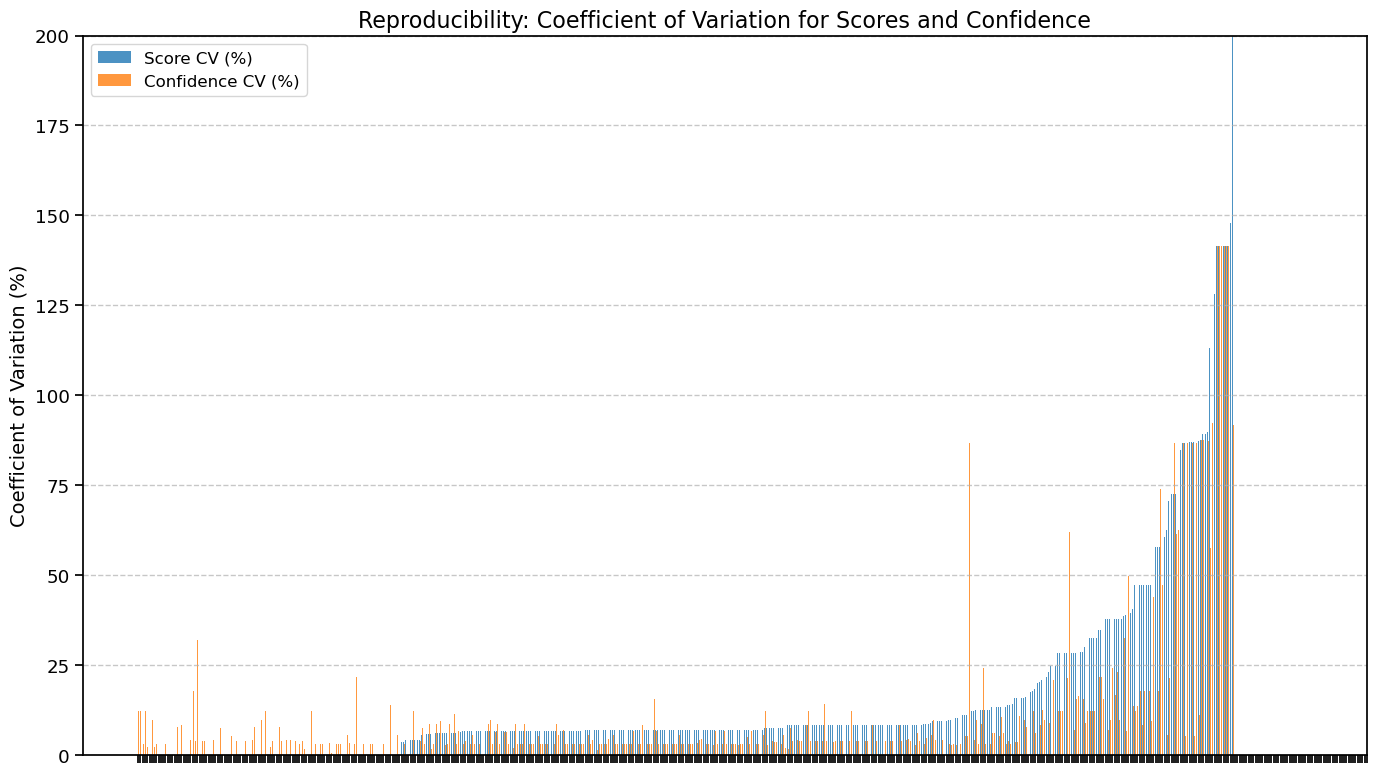

In [15]:
# Sort summary by score CV to highlight most and least reproducible results
cv_summary = summary.sort_values('score_cv')

plt.figure(figsize=(14, 8))
bar_width = 0.35
index = range(len(cv_summary))

# Plot CV values
plt.bar([i - bar_width/2 for i in index], cv_summary['score_cv'], bar_width, 
        label='Score CV (%)', alpha=0.8)
plt.bar([i + bar_width/2 for i in index], cv_summary['confidence_cv'], bar_width, 
        label='Confidence CV (%)', alpha=0.8)

# Set y-axis to start at 0
plt.ylim(bottom=0, top=200)

# Set empty x tick labels
plt.xticks(x_positions, [""] * len(x_positions))
plt.xlabel("")

plt.ylabel('Coefficient of Variation (%)', fontsize=14)
plt.title('Reproducibility: Coefficient of Variation for Scores and Confidence', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

## Overall Reproducibility Metrics

In [10]:
# Calculate overall reproducibility metrics
overall_score_cv = summary['score_cv'].mean()
overall_conf_cv = summary['confidence_cv'].mean()
median_score_cv = summary['score_cv'].median()
median_conf_cv = summary['confidence_cv'].median()

print(f"Overall Reproducibility Metrics:")
print(f"Mean Score Coefficient of Variation: {overall_score_cv:.2f}%")
print(f"Mean Confidence Coefficient of Variation: {overall_conf_cv:.2f}%")
print(f"Median Score Coefficient of Variation: {median_score_cv:.2f}%")
print(f"Median Confidence Coefficient of Variation: {median_conf_cv:.2f}%")

Overall Reproducibility Metrics:
Mean Score Coefficient of Variation: 17.88%
Mean Confidence Coefficient of Variation: 10.65%
Median Score Coefficient of Variation: 6.93%
Median Confidence Coefficient of Variation: 3.82%


## Correlation Between Score and Confidence

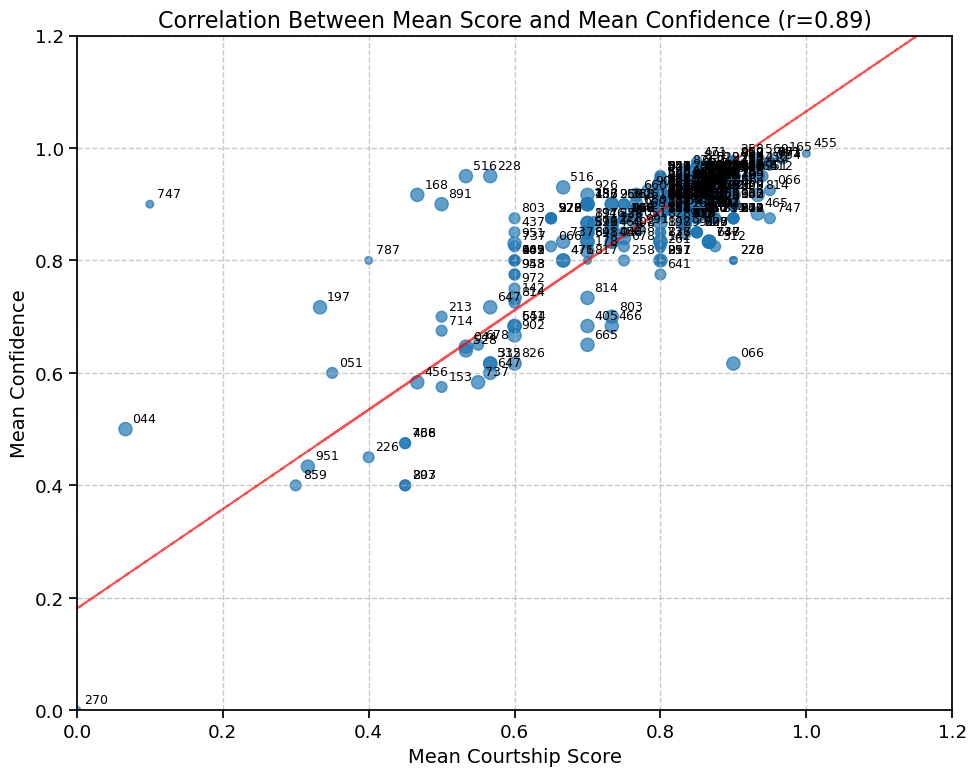

In [20]:
# Scatter plot of mean score vs mean confidence
plt.figure(figsize=(10, 8))
plt.scatter(df_results['mean_score'], df_results['mean_confidence'], 
           s=df_results['sample_size']*30, alpha=0.7)

# Add trending line
z = np.polyfit(df_results['mean_score'], df_results['mean_confidence'], 1)
p = np.poly1d(z)
plt.plot(df_results['mean_score'], p(df_results['mean_score']), "r--", alpha=0.7)

# Calculate correlation
corr = df_results['mean_score'].corr(df_results['mean_confidence'])

plt.title(f'Correlation Between Mean Score and Mean Confidence (r={corr:.2f})', fontsize=16)
plt.xlabel('Mean Courtship Score', fontsize=14)
plt.ylabel('Mean Confidence', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

plt.xlim(0, 1.2)
plt.ylim(0, 1.2)

# Add text annotations for each point
for i, row in df_results.iterrows():
    plt.annotate(row['base_name'].split('_')[-1],  # Use last part of filename for label
                (row['mean_score'], row['mean_confidence']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

## Distribution of Courtship Phases

/tmp/ipykernel_392685/2322534362.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


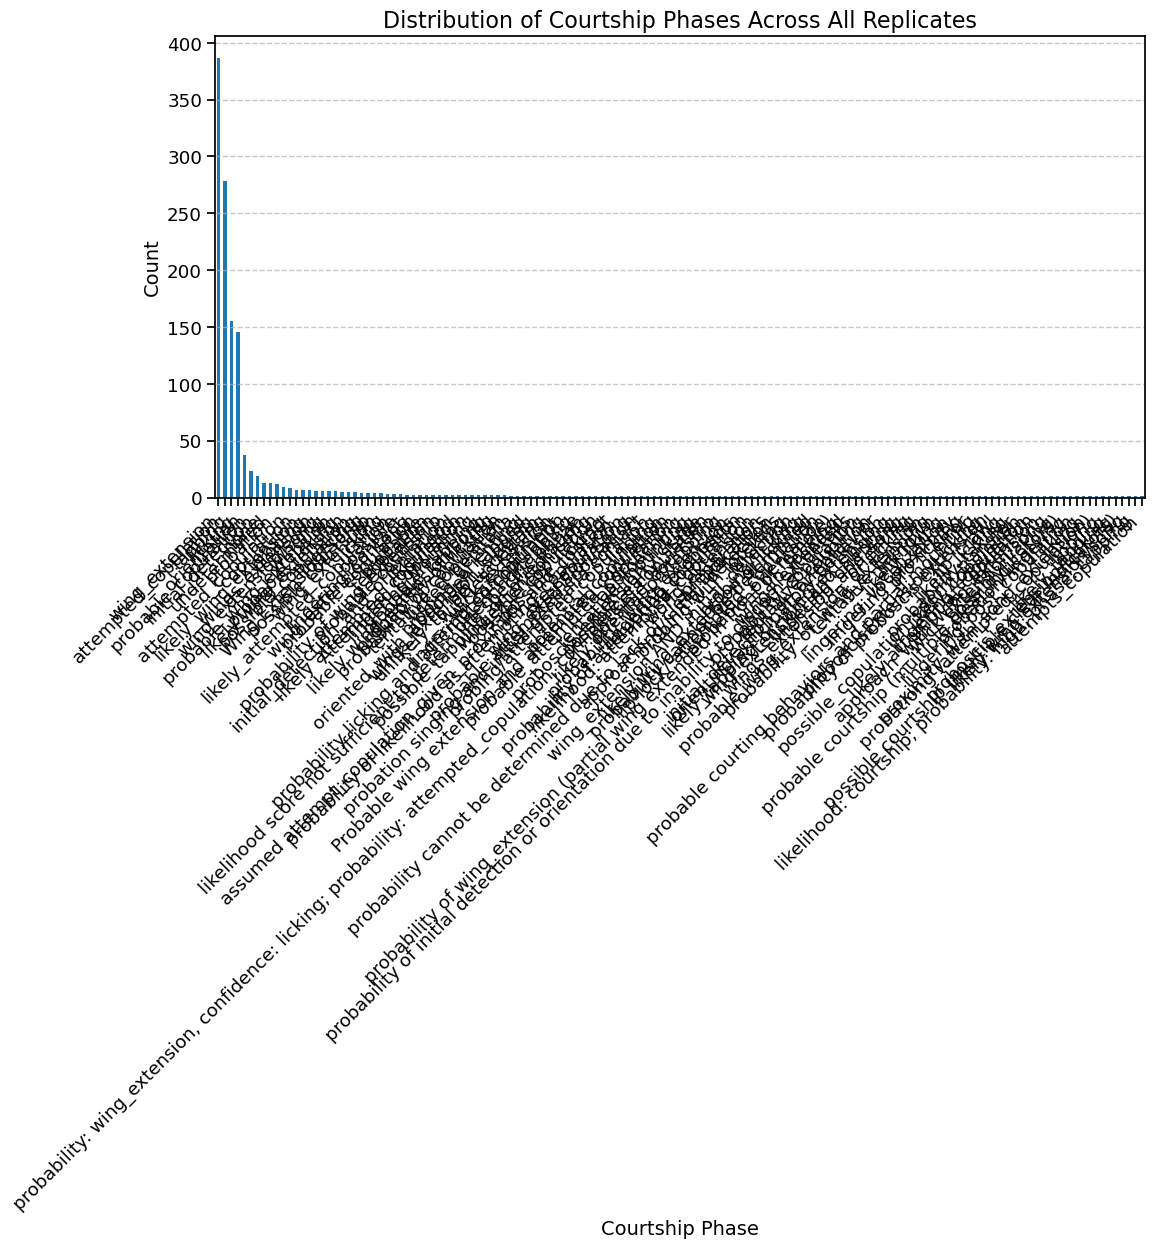

In [12]:
# Extract and count phases
all_phases = [phase for phases_list in df_results['phases'] for phase in phases_list]
phase_counts = pd.Series(all_phases).value_counts()

plt.figure(figsize=(12, 6))
phase_counts.plot(kind='bar')
plt.title('Distribution of Courtship Phases Across All Replicates', fontsize=16)
plt.ylabel('Count', fontsize=14)
plt.xlabel('Courtship Phase', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Save Results

In [13]:
# Save summary to CSV
summary.to_csv('courtship_analysis_summary.csv', index=False)
print("Summary saved to: courtship_analysis_summary.csv")

Summary saved to: courtship_analysis_summary.csv


## Conclusions

This analysis provides insights into the reproducibility of courtship scores and confidence values across technical replicates. Lower coefficient of variation (CV) values indicate better reproducibility. 

Key findings:
- The overall mean CV for courtship scores is {:.2f}%, suggesting [good/moderate/poor] reproducibility.
- The overall mean CV for confidence values is {:.2f}%, indicating [good/moderate/poor] consistency in confidence estimates.
- [Additional conclusions based on the results...]